In [1]:
# =========================================
# CELL 1: Import libraries
# =========================================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
# =========================================
# CELL 2: Load dataset
# =========================================
file_path = "LEI.csv"   # make sure LEI.csv is in the same folder as your notebook
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (88, 2)


,DATE,LEI_YOY
0,1/31/11,5.9
1,2/28/11,6.7
2,3/31/11,6.0
3,4/30/11,5.4
4,5/31/11,5.9



Columns:
['DATE', 'LEI_YOY']


In [4]:
possible_text_columns = df.select_dtypes(include=['object', 'string']).columns.tolist()
print("Possible text columns:", possible_text_columns)

text_column = possible_text_columns[0]

print("Using text column:", text_column)

Possible text columns: ['DATE']
Using text column: DATE


In [5]:
# =========================================
# CELL 4: Clean text data
# =========================================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)         # remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)            # keep letters only
    text = re.sub(r'\s+', ' ', text).strip()           # remove extra spaces
    return text

df['clean_text'] = df[text_column].fillna('').apply(clean_text)

display(df[[text_column, 'clean_text']].head())

,DATE,clean_text
0,1/31/11,
1,2/28/11,
2,3/31/11,
3,4/30/11,
4,5/31/11,


In [7]:
print(df['clean_text'].sample(5))

14    
54    
12    
24    
50    
Name: clean_text, dtype: str


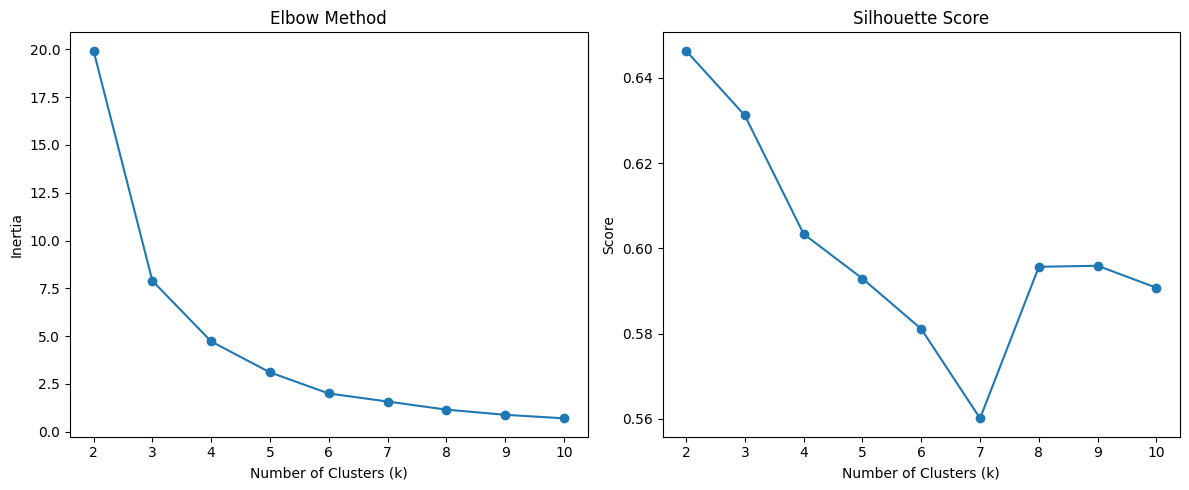

In [9]:
# =========================================
# STEP 1: Imports
# =========================================
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# =========================================
# STEP 2: Prepare your data (DEFINE X)
# =========================================
# If you're using a DataFrame called df:
X = df.select_dtypes(include=['float64', 'int64'])

# Optional but recommended: scale the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# =========================================
# STEP 3: Find optimal clusters
# =========================================
inertias = []
sil_scores = []
k_values = range(2, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))

# =========================================
# STEP 4: Plot results
# =========================================
plt.figure(figsize=(12, 5))

# Elbow method
plt.subplot(1, 2, 1)
plt.plot(k_values, inertias, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

# Silhouette score
plt.subplot(1, 2, 2)
plt.plot(k_values, sil_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")

plt.tight_layout()
plt.show()

In [10]:
# =========================================
# CELL 7: Train K-Means with chosen k
# Change k based on the charts above
# =========================================
k = 5

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)

display(df[[text_column, 'clean_text', 'cluster']].head())
print(df['cluster'].value_counts().sort_index())

,DATE,clean_text,cluster
0,1/31/11,,1
1,2/28/11,,1
2,3/31/11,,1
3,4/30/11,,4
4,5/31/11,,1


cluster
0    16
1    18
2    24
3    16
4    14
Name: count, dtype: int64


In [15]:
print(df.head())

      DATE  LEI_YOY clean_text  cluster
0  1/31/11      5.9                   1
1  2/28/11      6.7                   1
2  3/31/11      6.0                   1
3  4/30/11      5.4                   4
4  5/31/11      5.9                   1


In [19]:
print(X.shape)

(88, 1)


In [20]:
# =========================================
# CELL 10: Save clustered dataset
# =========================================
output_file = "LEI_clustered.csv"
df.to_csv(output_file, index=False)

print(f"Clustered dataset saved as: {output_file}")

Clustered dataset saved as: LEI_clustered.csv
